# Modelos Supervisionados

Como descrito no [projeto](https://github.com/LeoBardineo/trabalho-ufrj-iml), esse notebook faz parte de um problema de classificação de URLs de phishing. O dataset utilizado é o [PhiUSIIL Phishing Url](https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+website+dataset).

Aqui será feito os modelos supervisionados:
- Árvore de Decisão, que sevirá como baseline e nos permitirá auditoria em relação a que regras o modelo levou em questão para a classificação
- XGBoost, que é o padrão de indústria atualmente e nos dará um modelo baseado em árvores mais preciso.

Para cada modelo será medido as métricas tempo de inferência, matriz de confusão, precision, recall, F1-Score. E enfim, feito uma conclusão sobre qual modelo pode ser mais adequado em certos contextos.


## Setup

### Importando bibliotecas

In [25]:
# @title
import time
import joblib
import os

from google.colab import drive

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

### Configurações adicionais

In [32]:
sns.set_theme(style="whitegrid")

In [3]:
drive.mount('/content/drive')
drive_folder = '/content/drive/MyDrive/PipeML'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Funções utilitárias

Salvamos os datasets em .csv na etapa de pré processamento em um drive público, aqui carregamos pelo id do csv no drive

In [4]:
# @title
def load_drive_csv(csv_id, drop_cols = []):
    url = f'https://drive.google.com/uc?export=download&id={csv_id}'
    try:
        df = pd.read_csv(url)
    except Exception as e:
        raise RuntimeError(f"Falha ao carregar dataset de id {csv_id}. \nErro: {e}")
    cols_to_drop = [c for c in drop_cols if c in df.columns]
    return df.drop(columns=cols_to_drop)

Treino, criação dos splits (stratified k fold), e comparação dos modelos em uma tabela

In [5]:
# @title
def treinar_base(ModelClass, splits, **model_kwargs):
    base_results = {}

    for dataset_name, split in splits.items():
        model = ModelClass(**model_kwargs)

        start = time.time()
        model.fit(split['X_train'], split['y_train'])
        elapsed = time.time() - start

        base_results[dataset_name] = {'estimator': model}

        print(f"[{dataset_name}]")
        print("Parâmetros:")
        display(model.get_params())
        print(f"Tempo de treino: {elapsed:.1f}s\n")

    return base_results


def treinar_grid_search(ModelClass, splits, param_grid, cv, **model_kwargs):
    tuned_results = {}

    for dataset_name, split in splits.items():
        print(f"Treinando {ModelClass.__name__} com Grid Search em [{dataset_name}]...")

        grid_search = GridSearchCV(
            estimator=ModelClass(**model_kwargs),
            param_grid=param_grid,
            scoring='f1',
            cv=cv,
            n_jobs=-1,
            verbose=1,
        )

        start = time.time()
        grid_search.fit(split['X_train'], split['y_train'])
        elapsed = time.time() - start

        tuned_results[dataset_name] = {
            'best_estimator': grid_search.best_estimator_,
            'best_params':    grid_search.best_params_,
            'best_cv_f1':     grid_search.best_score_,
            'train_time':     elapsed,
        }

        print(f"  Melhores parâmetros: {grid_search.best_params_}")
        print(f"  F1 médio nos folds:  {grid_search.best_score_:.4f}")
        print(f"  Tempo de treino:     {elapsed:.1f}s\n")

    return tuned_results

def criar_splits(datasets):
    splits = {}

    for name, dataset in datasets.items():
        X = dataset.drop(columns=['label']).select_dtypes(include=[np.number])
        y = dataset['label']

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        splits[name] = {
            'X_train': X_train,
            'X_test':  X_test,
            'y_train': y_train,
            'y_test':  y_test,
        }

        print(f"[{name}] Treino: {X_train.shape} | Teste: {X_test.shape} | Proporção de phishing no treino: {y_train.mean():.2%}")

    return splits

def comparar_modelos(base_results, tuned_results, splits):
    print(f"{'Dataset':<15} | {'Modelo':<20} | {'Precision':>10} | {'Recall':>10} | {'F1':>10} | {'Inferência':>12}")
    print("-" * 90)

    for dataset_name, split in splits.items():
        X_test = split['X_test']
        y_test = split['y_test']

        models = {
            'Base':      base_results[dataset_name]['estimator'],
            'Otimizado': tuned_results[dataset_name]['best_estimator'],
        }

        for model_name, model in models.items():
            start = time.time()
            y_pred = model.predict(X_test)
            inference_time = time.time() - start

            print(
                f"{dataset_name:<15} | "
                f"{model_name:<20} | "
                f"{precision_score(y_test, y_pred):>10.4f} | "
                f"{recall_score(y_test, y_pred):>10.4f} | "
                f"{f1_score(y_test, y_pred):>10.4f} | "
                f"{inference_time:>11.4f}s"
            )


Treinar e salvar, ou carregar modelos

In [6]:
# @title
def carregar_ou_treinar_base(ModelClass, nome, splits, **model_kwargs):
    path = f'{drive_folder}/{nome}.pkl'

    if os.path.exists(path):
        print(f"Carregando {nome} do Drive...")
        return joblib.load(path)

    print(f"Modelo {nome} não encontrado, treinando...")
    results = treinar_base(ModelClass, splits, **model_kwargs)

    os.makedirs(drive_folder, exist_ok=True)
    joblib.dump(results, path)
    print(f"Salvo em {path}")

    return results


def carregar_ou_treinar_grid_search(ModelClass, nome, splits, param_grid, cv, **model_kwargs):
    path = f'{drive_folder}/{nome}.pkl'

    if os.path.exists(path):
        print(f"Carregando {nome} do Drive...")
        return joblib.load(path)

    print(f"Modelo {nome} não encontrado, treinando...")
    results = treinar_grid_search(ModelClass, splits, param_grid, cv, **model_kwargs)

    os.makedirs(drive_folder, exist_ok=True)
    joblib.dump(results, path)
    print(f"Salvo em {path}")

    return results

Interpretabilidade dos modelos

In [30]:
# @title
# Feature importance da árvore de decisão
def plotar_importancia_dt(dt_results, splits, titulo):
    datasets_reduzidos = {k: v for k, v in splits.items() if k != 'df'}

    fig, axes = plt.subplots(1, len(datasets_reduzidos), figsize=(18, 5))
    fig.suptitle(f'Feature Importance — Decision Tree Otimizado | {titulo}', fontsize=13)

    if len(datasets_reduzidos) == 1:
        axes = [axes]

    for ax, (dataset_name, split) in zip(axes, datasets_reduzidos.items()):
        model = dt_results[dataset_name]['best_estimator']
        feature_names = split['X_train'].columns

        importances = pd.Series(model.feature_importances_, index=feature_names)
        top10 = importances.nlargest(10).sort_values()

        ax.barh(top10.index, top10.values)
        ax.set_title(dataset_name)
        ax.set_xlabel('Importância')

    plt.tight_layout()
    plt.show()

# Feature importance do XGBoost
def plotar_importancia_xgb(xgb_results, splits, titulo):
    datasets_reduzidos = {k: v for k, v in splits.items() if k != 'df'}

    fig, axes = plt.subplots(1, len(datasets_reduzidos), figsize=(18, 5))
    fig.suptitle(f'Feature Importance — XGBoost Otimizado | {titulo}', fontsize=13)

    if len(datasets_reduzidos) == 1:
        axes = [axes]

    for ax, (dataset_name, split) in zip(axes, datasets_reduzidos.items()):
        model = xgb_results[dataset_name]['best_estimator']
        feature_names = split['X_train'].columns

        importances = pd.Series(model.feature_importances_, index=feature_names)
        top10 = importances.nlargest(10).sort_values()

        ax.barh(top10.index, top10.values)
        ax.set_title(dataset_name)
        ax.set_xlabel('Importância')

    plt.tight_layout()
    plt.show()

# Plot árvore de decisão
def plotar_arvore_decisao(dt_results, splits, titulo, max_depth, dataset_name='df_35'):
    print(f"\nPlot da Árvore de Decisão ({dataset_name}, max_depth={max_depth}) | {titulo}")

    model = dt_results[dataset_name]['best_estimator']
    feature_names = splits[dataset_name]['X_train'].columns

    fig, ax = plt.subplots(figsize=(20, 8))
    plot_tree(
        model,
        feature_names=feature_names,
        class_names=['Legítimo', 'Phishing'],
        filled=True,
        max_depth=max_depth,
        ax=ax,
        fontsize=8,
    )
    plt.title(f'Árvore de Decisão — {dataset_name} (max_depth={max_depth}) | {titulo}')
    plt.tight_layout()
    plt.show()

### Carregando datasets

In [7]:
dataset_ids = {
    'df':    '1gbfFzWO0A13gcKCULvnwdPaoY-cUeqoN',
    'df_46': '1LXtyTZK0RXPhjFsVIFLcScW7JXSdC8CH',
    'df_45': '15WFduozUE2p88LigOMzJ9fa7uxEpSJAj',
    'df_35': '1snEz-tUsKV8BBlbc74v7qWTfTfnhPyVR',
}
drop_cols = ['FILENAME']

datasets = {name: load_drive_csv(csv_id, drop_cols) for name, csv_id in dataset_ids.items()}

df    = datasets['df']
df_46 = datasets['df_46']
df_45 = datasets['df_45']
df_35 = datasets['df_35']

## Pré processamento

### Separação dos datasets para treino e teste

Antes de qualquer treinamento, separamos cada dataset em treino e teste, com propoção respectiva de 80/20.

O conjuto de treino será usado para os algoritmos aprenderem os padrões acerca do dataset.

O conjunto de teste é reservado exclusivamente para a avaliação final dos modelos, nunca sendo visto durante o treinamento ou a busca de hiperparâmetros.

A validação durante o Grid Search ocorre internamente via Stratified K-Fold sobre o conjunto de treino, portanto não é necessário separar um terceiro conjunto de validação manualmente.

In [8]:
splits = criar_splits(datasets)

[df] Treino: (188636, 50) | Teste: (47159, 50) | Proporção de phishing no treino: 57.19%
[df_46] Treino: (188636, 45) | Teste: (47159, 45) | Proporção de phishing no treino: 57.19%
[df_45] Treino: (188636, 44) | Teste: (47159, 44) | Proporção de phishing no treino: 57.19%
[df_35] Treino: (188636, 34) | Teste: (47159, 34) | Proporção de phishing no treino: 57.19%


O parâmetro `stratify=y` garante que a proporção entre URLs legítimas e de phishing seja mantida em ambos os conjuntos. É importante pois, mesmo que o dataset tenha as classes balanceadas, esse parâmetro evita que por acaso um dos conjuntos fique com uma distribuição diferente do dataset completo.

O `random_state=42` é a seed do método, garatindo que será feito a mesma separação toda vez que for rodado.


### Busca de hiperparâmetros

Para que todos os modelos possam performar melhor, todos passam pelo Grid Search com Stratified K-Fold.

O Grid Search testa sistematicamente combinações de hiperparâmetros e seleciona a que obtiver melhor F1-Score médio nos folds, métrica escolhida por equilibrar Precision e Recall.

O Stratified K-Fold com 5 folds é usado como estratégia de validação interna do Grid Search, garantindo que a proporção de classes seja mantida em cada fold e que o modelo seja avaliado em diferentes partições do conjunto de treino antes de ser considerado otimizado. A escolha do k = 5 faz com que os dados sejam divididos em 5, com 4 sendo uosados para treinar e 1 para validar. A escolha de um k menor treinaria os modelos com poucos dados, tornando o modelo pior, e um k maior deixaria o treinamento muito custoso por ter mais combinações para testar, tomando muito mais tempo.

Esse processo é repetido para cada um dos 4 datasets, resultando nos melhores modelos para cada combinação de algoritmo e conjunto de features. O único problema é que a duração do treinamento aumenta bastante.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Árvore de Decisão

### Definindo o modelo base

Sem o Grid Search, utilizando os parâmetros padrão do `.fit`, temos um modelo padrão, sem otimização de hiperparâmetros.

In [10]:
dt_base_results = carregar_ou_treinar_base(DecisionTreeClassifier, 'dt_base', splits, random_state=42)

Modelo dt_base não encontrado, treinando...
[df]
Parâmetros:


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

Tempo de treino: 0.8s

[df_46]
Parâmetros:


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

Tempo de treino: 2.9s

[df_45]
Parâmetros:


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

Tempo de treino: 3.1s

[df_35]
Parâmetros:


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

Tempo de treino: 4.3s

Salvo em /content/drive/MyDrive/PipeML/dt_base.pkl


Como não há otimização dos hiperparâmetros, todos são iguais, são os defaults do scikit-learn. Os mais relevantes para entender o comportamento do modelo são `max_depth: None`, que permite que a árvore cresça sem limite de profundidade até separar completamente os dados de treino, e `min_samples_split: 2`, que permite divisões em nós com apenas 2 amostras. Essa combinação tende a gerar árvores muito profundas e com overfitting, memorizando o conjunto de treino em vez de generalizar padrões.

O tempo de treino reflete diretamente esse comportamento: o `df` original treinou em apenas 0.8s pois, como visto na análise de dados, o `URLSimilarityIndex` permite separar as classes com pouquíssimas divisões. Já os datasets reduzidos sem essa feature dominante, exigiram árvores mais profundas para separar os dados, resultando em tempos maiores: 2.8s, 3.7s e 2.9s para os datasets de 46, 45 e 35 features respectivamente.

### Grid Search

In [11]:
dt_param_grid = {
    'max_depth':         [5, 10, 20, None],
    'min_samples_split': [2, 10, 50],
    'criterion':         ['gini', 'entropy'],
}
dt_results = carregar_ou_treinar_grid_search(DecisionTreeClassifier, 'dt_results', splits, dt_param_grid, cv, random_state=42)

Modelo dt_results não encontrado, treinando...
Treinando DecisionTreeClassifier com Grid Search em [df]...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Melhores parâmetros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
  F1 médio nos folds:  1.0000
  Tempo de treino:     82.8s

Treinando DecisionTreeClassifier com Grid Search em [df_46]...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Melhores parâmetros: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 2}
  F1 médio nos folds:  0.9993
  Tempo de treino:     162.6s

Treinando DecisionTreeClassifier com Grid Search em [df_45]...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Melhores parâmetros: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 2}
  F1 médio nos folds:  0.9993
  Tempo de treino:     163.9s

Treinando DecisionTreeClassifier com Grid Search em [df_35]...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Melhores 

A partir do Grid Search, podemos observar que houve F1 de 1.0 no df original. Isso porque, como investigado na análise de dados, há features que praticamente entregam o que a URL é, tendo assim um overfitting. Isso pode ser reforçado pela escolha do parâmetro `max_depth`, que no df original é apenas 5, produzindo uma árvore rasa e menos tempo de treinamento, enquanto nos dfs reduzidos chega a 20, quase dobrando o tempo de treinamento.

### Comparação entre modelos com parâmetros base vs otimizado

Avaliamos ambos os modelos no conjunto de teste.

No dataset original, ambos atingem métricas perfeitas, o que reforça a conclusão anterior de que há features que tornam a classificação fácil, independente de otimização de hiperparâmetros.

Nos datasets reduzidos, os ganhos do modelo otimizado são poucos, com variações de no máximo +0.0006 em Recall e F1, e -0.004s em tempo de inferência. Isso sugere que a árvore de decisão com parâmetros padrões já é suficientemente boa para esse dataset, e que o custo computacional do Grid Search, em torno de 130s por dataset, não se justifica pelo ganho obtido.

Esse resultado será retomado na conclusão, na comparação com o XGBoost.

In [12]:
comparar_modelos(dt_base_results, dt_results, splits)

Dataset         | Modelo               |  Precision |     Recall |         F1 |   Inferência
------------------------------------------------------------------------------------------
df              | Base                 |     1.0000 |     1.0000 |     1.0000 |      0.0130s
df              | Otimizado            |     1.0000 |     1.0000 |     1.0000 |      0.0113s
df_46           | Base                 |     0.9991 |     0.9989 |     0.9990 |      0.0140s
df_46           | Otimizado            |     0.9994 |     0.9992 |     0.9993 |      0.0106s
df_45           | Base                 |     0.9994 |     0.9987 |     0.9991 |      0.0120s
df_45           | Otimizado            |     0.9994 |     0.9992 |     0.9993 |      0.0111s
df_35           | Base                 |     0.9990 |     0.9985 |     0.9988 |      0.0116s
df_35           | Otimizado            |     0.9990 |     0.9991 |     0.9991 |      0.0104s


## XGBoost

### Definindo o modelo base

In [13]:
xgb_base_results = carregar_ou_treinar_base(XGBClassifier, 'xgb_base', splits, random_state=42, n_jobs=-1, eval_metric='logloss')

Modelo xgb_base não encontrado, treinando...
[df]
Parâmetros:


{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

Tempo de treino: 2.7s

[df_46]
Parâmetros:


{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

Tempo de treino: 6.0s

[df_45]
Parâmetros:


{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

Tempo de treino: 2.8s

[df_35]
Parâmetros:


{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

Tempo de treino: 2.5s

Salvo em /content/drive/MyDrive/PipeML/xgb_base.pkl


### Grid Search

In [14]:
xgb_param_grid = {
    'n_estimators':  [100, 300],
    'max_depth':     [4, 6],
    'learning_rate': [0.05, 0.3],
}
xgb_results = carregar_ou_treinar_grid_search(XGBClassifier, 'xgb_results', splits, xgb_param_grid, cv, random_state=42, n_jobs=-1, eval_metric='logloss')

Modelo xgb_results não encontrado, treinando...
Treinando XGBClassifier com Grid Search em [df]...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
  F1 médio nos folds:  1.0000
  Tempo de treino:     165.5s

Treinando XGBClassifier com Grid Search em [df_46]...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Melhores parâmetros: {'learning_rate': 0.3, 'max_depth': 4, 'n_estimators': 300}
  F1 médio nos folds:  0.9999
  Tempo de treino:     191.9s

Treinando XGBClassifier com Grid Search em [df_45]...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Melhores parâmetros: {'learning_rate': 0.3, 'max_depth': 4, 'n_estimators': 300}
  F1 médio nos folds:  0.9999
  Tempo de treino:     189.4s

Treinando XGBClassifier com Grid Search em [df_35]...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Melhores parâmetros: {'learning_rate': 0.3, 'max_depth': 4, 'n_e

### Comparação base vs otimizado

In [15]:
comparar_modelos(xgb_base_results, xgb_results, splits)

Dataset         | Modelo               |  Precision |     Recall |         F1 |   Inferência
------------------------------------------------------------------------------------------
df              | Base                 |     1.0000 |     1.0000 |     1.0000 |      0.0680s
df              | Otimizado            |     1.0000 |     1.0000 |     1.0000 |      0.0812s
df_46           | Base                 |     1.0000 |     1.0000 |     1.0000 |      0.0922s
df_46           | Otimizado            |     1.0000 |     1.0000 |     1.0000 |      0.1729s
df_45           | Base                 |     1.0000 |     1.0000 |     1.0000 |      0.0915s
df_45           | Otimizado            |     1.0000 |     1.0000 |     1.0000 |      0.1945s
df_35           | Base                 |     0.9999 |     1.0000 |     0.9999 |      0.0872s
df_35           | Otimizado            |     1.0000 |     1.0000 |     1.0000 |      0.1724s


## Retirando features causando data leakage e retreinando modelo

Como observado pelas métricas, ambos os modelos atingiram valores muito próximos ou iguais a 1.0 em todos os datasets. Isso levanta a suspeita de que os datasets ainda contem features correlacionadas até demais com a label, entregando a classificação de bandeija na presença dessas features.

Essa hipótese é confirmada pela análise de correlação de Spearman realizada na EDA, 8 features apresentam correlação acima de 0.70 com o label, sendo `NoOfExternalRef` a maior, com 0.8426.

Isso não significa que as features são inválidas, sites legítimos de fato tendem a ter mais referências externas, mais imagens e mais código que páginas de phishing. O problema é que no dataset esses padrões são tão marcantes que condicionam excessivamente os modelos, o que pode não refletir a diversidade de URLs encontradas em produção.

Para avaliar o comportamento dos modelos sem essa influência, removemos as 8 features com correlação de Spearman acima de 0.70 e repetimos todo o fluxo de treinamento e avaliação.

In [16]:
features_correlacionadas = [
    'NoOfExternalRef',
    'NoOfImage',
    'LineOfCode',
    'NoOfSelfRef',
    'NoOfJS',
    'NoOfCSS',
    'HasSocialNet',
    'HasCopyrightInfo',
]

datasets_sem_leakage = {
    name: dataset.drop(columns=[c for c in features_correlacionadas if c in dataset.columns])
    for name, dataset in datasets.items()
}

splits_sem_leakage = criar_splits(datasets_sem_leakage)

[df] Treino: (188636, 42) | Teste: (47159, 42) | Proporção de phishing no treino: 57.19%
[df_46] Treino: (188636, 37) | Teste: (47159, 37) | Proporção de phishing no treino: 57.19%
[df_45] Treino: (188636, 36) | Teste: (47159, 36) | Proporção de phishing no treino: 57.19%
[df_35] Treino: (188636, 26) | Teste: (47159, 26) | Proporção de phishing no treino: 57.19%


### Árvore de decisão

In [17]:
dt_base_results_sl = carregar_ou_treinar_base(DecisionTreeClassifier, 'dt_base_sl', splits_sem_leakage, random_state=42)

Modelo dt_base_sl não encontrado, treinando...
[df]
Parâmetros:


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

Tempo de treino: 1.0s

[df_46]
Parâmetros:


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

Tempo de treino: 1.9s

[df_45]
Parâmetros:


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

Tempo de treino: 1.9s

[df_35]
Parâmetros:


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

Tempo de treino: 2.1s

Salvo em /content/drive/MyDrive/PipeML/dt_base_sl.pkl


In [18]:
dt_results_sl = carregar_ou_treinar_grid_search(DecisionTreeClassifier, 'dt_results_sl', splits_sem_leakage, dt_param_grid, cv, random_state=42)

Modelo dt_results_sl não encontrado, treinando...
Treinando DecisionTreeClassifier com Grid Search em [df]...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Melhores parâmetros: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}
  F1 médio nos folds:  1.0000
  Tempo de treino:     78.1s

Treinando DecisionTreeClassifier com Grid Search em [df_46]...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Melhores parâmetros: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 2}
  F1 médio nos folds:  0.9983
  Tempo de treino:     115.6s

Treinando DecisionTreeClassifier com Grid Search em [df_45]...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Melhores parâmetros: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 2}
  F1 médio nos folds:  0.9983
  Tempo de treino:     117.8s

Treinando DecisionTreeClassifier com Grid Search em [df_35]...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Me

In [19]:
comparar_modelos(dt_base_results_sl, dt_results_sl, splits_sem_leakage)

Dataset         | Modelo               |  Precision |     Recall |         F1 |   Inferência
------------------------------------------------------------------------------------------
df              | Base                 |     0.9999 |     1.0000 |     0.9999 |      0.0194s
df              | Otimizado            |     0.9998 |     1.0000 |     0.9999 |      0.0137s
df_46           | Base                 |     0.9977 |     0.9978 |     0.9977 |      0.0156s
df_46           | Otimizado            |     0.9988 |     0.9985 |     0.9986 |      0.0138s
df_45           | Base                 |     0.9974 |     0.9977 |     0.9975 |      0.0157s
df_45           | Otimizado            |     0.9988 |     0.9987 |     0.9988 |      0.0139s
df_35           | Base                 |     0.9976 |     0.9977 |     0.9976 |      0.0138s
df_35           | Otimizado            |     0.9986 |     0.9985 |     0.9985 |      0.0114s


### XGBoost

In [20]:
xgb_base_results_sl = carregar_ou_treinar_base(XGBClassifier, 'xgb_base_sl', splits_sem_leakage, random_state=42, n_jobs=-1, eval_metric='logloss')

Modelo xgb_base_sl não encontrado, treinando...
[df]
Parâmetros:


{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

Tempo de treino: 5.5s

[df_46]
Parâmetros:


{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

Tempo de treino: 3.2s

[df_45]
Parâmetros:


{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

Tempo de treino: 2.9s

[df_35]
Parâmetros:


{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

Tempo de treino: 2.2s

Salvo em /content/drive/MyDrive/PipeML/xgb_base_sl.pkl


In [21]:
xgb_results_sl = carregar_ou_treinar_grid_search(XGBClassifier, 'xgb_results_sl', splits_sem_leakage, xgb_param_grid, cv, random_state=42, n_jobs=-1, eval_metric='logloss')

Modelo xgb_results_sl não encontrado, treinando...
Treinando XGBClassifier com Grid Search em [df]...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Melhores parâmetros: {'learning_rate': 0.3, 'max_depth': 4, 'n_estimators': 300}
  F1 médio nos folds:  1.0000
  Tempo de treino:     169.8s

Treinando XGBClassifier com Grid Search em [df_46]...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Melhores parâmetros: {'learning_rate': 0.3, 'max_depth': 4, 'n_estimators': 300}
  F1 médio nos folds:  0.9993
  Tempo de treino:     181.0s

Treinando XGBClassifier com Grid Search em [df_45]...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Melhores parâmetros: {'learning_rate': 0.3, 'max_depth': 4, 'n_estimators': 300}
  F1 médio nos folds:  0.9993
  Tempo de treino:     175.6s

Treinando XGBClassifier com Grid Search em [df_35]...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Melhores parâmetros: {'learning_rate': 0.3, 'max_depth': 4, 'n

In [22]:
comparar_modelos(xgb_base_results_sl, xgb_results_sl, splits_sem_leakage)

Dataset         | Modelo               |  Precision |     Recall |         F1 |   Inferência
------------------------------------------------------------------------------------------
df              | Base                 |     1.0000 |     1.0000 |     1.0000 |      0.0831s
df              | Otimizado            |     1.0000 |     1.0000 |     1.0000 |      0.1944s
df_46           | Base                 |     0.9991 |     0.9997 |     0.9994 |      0.1850s
df_46           | Otimizado            |     0.9993 |     0.9997 |     0.9995 |      0.3853s
df_45           | Base                 |     0.9991 |     0.9997 |     0.9994 |      0.2150s
df_45           | Otimizado            |     0.9993 |     0.9997 |     0.9995 |      0.4345s
df_35           | Base                 |     0.9993 |     0.9997 |     0.9995 |      0.2182s
df_35           | Otimizado            |     0.9993 |     0.9998 |     0.9996 |      0.3499s


## Comparação entre os modelos

Tabela consolidada com os modelos lado a lado e gráficos de barra comparando as métricas visualmente.

(Matriz de confusão, Precision, Recall e F1-Score, Tempo de inferência)

In [23]:
# @title
def comparar_todos_modelos(resultados, splits, titulo):
    modelos = {
        'Decision Tree Base':      (resultados['dt_base'],  'estimator'),
        'Decision Tree Otimizado': (resultados['dt'],       'best_estimator'),
        'XGBoost Base':            (resultados['xgb_base'], 'estimator'),
        'XGBoost Otimizado':       (resultados['xgb'],      'best_estimator'),
    }

    datasets_reduzidos = {k: v for k, v in splits.items() if k != 'df'}
    nomes_modelos = list(modelos.keys())
    nomes_datasets = list(datasets_reduzidos.keys())

    print(f"\n{'='*90}")
    print(f" {titulo}")
    print(f"{'='*90}")
    print(f"{'Dataset':<10} {'Modelo':<25} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Inferência':>12}")
    print(f"{'-'*90}")

    tabela = {nome: {col: [] for col in ['Precision', 'Recall', 'F1', 'Inferência']} for nome in nomes_modelos}

    for dataset_name, split in datasets_reduzidos.items():
        X_test = split['X_test']
        y_test = split['y_test']

        for model_name, (result, key) in modelos.items():
            model = result[dataset_name][key]

            start = time.time()
            y_pred = model.predict(X_test)
            inference_time = time.time() - start

            p = precision_score(y_test, y_pred)
            r = recall_score(y_test, y_pred)
            f = f1_score(y_test, y_pred)

            tabela[model_name]['Precision'].append(p)
            tabela[model_name]['Recall'].append(r)
            tabela[model_name]['F1'].append(f)
            tabela[model_name]['Inferência'].append(inference_time)

            print(f"{dataset_name:<10} {model_name:<25} {p:>10.4f} {r:>10.4f} {f:>10.4f} {inference_time:>11.4f}s")

    # Gráficos de barra por métrica
    metricas = ['Precision', 'Recall', 'F1']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(titulo, fontsize=13)
    x = np.arange(len(nomes_datasets))
    width = 0.2

    for ax, metrica in zip(axes, metricas):
        for i, model_name in enumerate(nomes_modelos):
            ax.bar(x + i * width, tabela[model_name][metrica], width, label=model_name)
        ax.set_title(metrica)
        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels(nomes_datasets)
        ax.set_ylim(0.99, 1.001)
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

    # Matrizes de confusão
    fig, axes = plt.subplots(len(nomes_modelos), len(nomes_datasets), figsize=(14, 16))
    fig.suptitle(f'Matrizes de Confusão — {titulo}', fontsize=13)

    for i, (model_name, (result, key)) in enumerate(modelos.items()):
        for j, (dataset_name, split) in enumerate(datasets_reduzidos.items()):
            model = result[dataset_name][key]
            y_pred = model.predict(split['X_test'])
            cm = confusion_matrix(split['y_test'], y_pred)

            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i][j],
                        xticklabels=['Legítimo', 'Phishing'],
                        yticklabels=['Legítimo', 'Phishing'])
            axes[i][j].set_title(f'{model_name}\n{dataset_name}', fontsize=9)
            axes[i][j].set_xlabel('Predito')
            axes[i][j].set_ylabel('Real')

    plt.tight_layout()
    plt.show()


resultados_original = {
    'dt_base':  dt_base_results,
    'dt':       dt_results,
    'xgb_base': xgb_base_results,
    'xgb':      xgb_results,
}

resultados_sem_leakage = {
    'dt_base':  dt_base_results_sl,
    'dt':       dt_results_sl,
    'xgb_base': xgb_base_results_sl,
    'xgb':      xgb_results_sl,
}


 Com features corr >= 0.7
Dataset    Modelo                     Precision     Recall         F1   Inferência
------------------------------------------------------------------------------------------
df_46      Decision Tree Base            0.9991     0.9989     0.9990      0.1449s
df_46      Decision Tree Otimizado       0.9994     0.9992     0.9993      0.0408s
df_46      XGBoost Base                  1.0000     1.0000     1.0000      0.2992s
df_46      XGBoost Otimizado             1.0000     1.0000     1.0000      0.3761s
df_45      Decision Tree Base            0.9994     0.9987     0.9991      0.0867s
df_45      Decision Tree Otimizado       0.9994     0.9992     0.9993      0.0181s
df_45      XGBoost Base                  1.0000     1.0000     1.0000      0.1902s
df_45      XGBoost Otimizado             1.0000     1.0000     1.0000      0.2586s
df_35      Decision Tree Base            0.9990     0.9985     0.9988      0.0775s
df_35      Decision Tree Otimizado       0.9990     

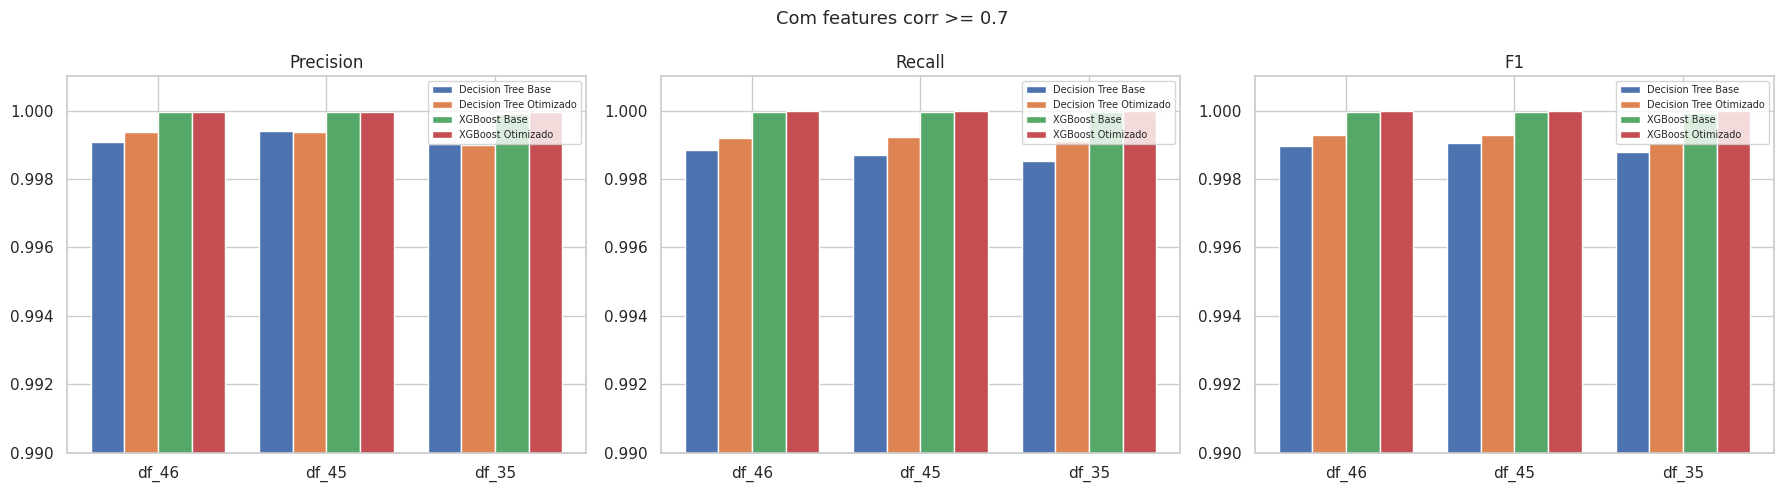

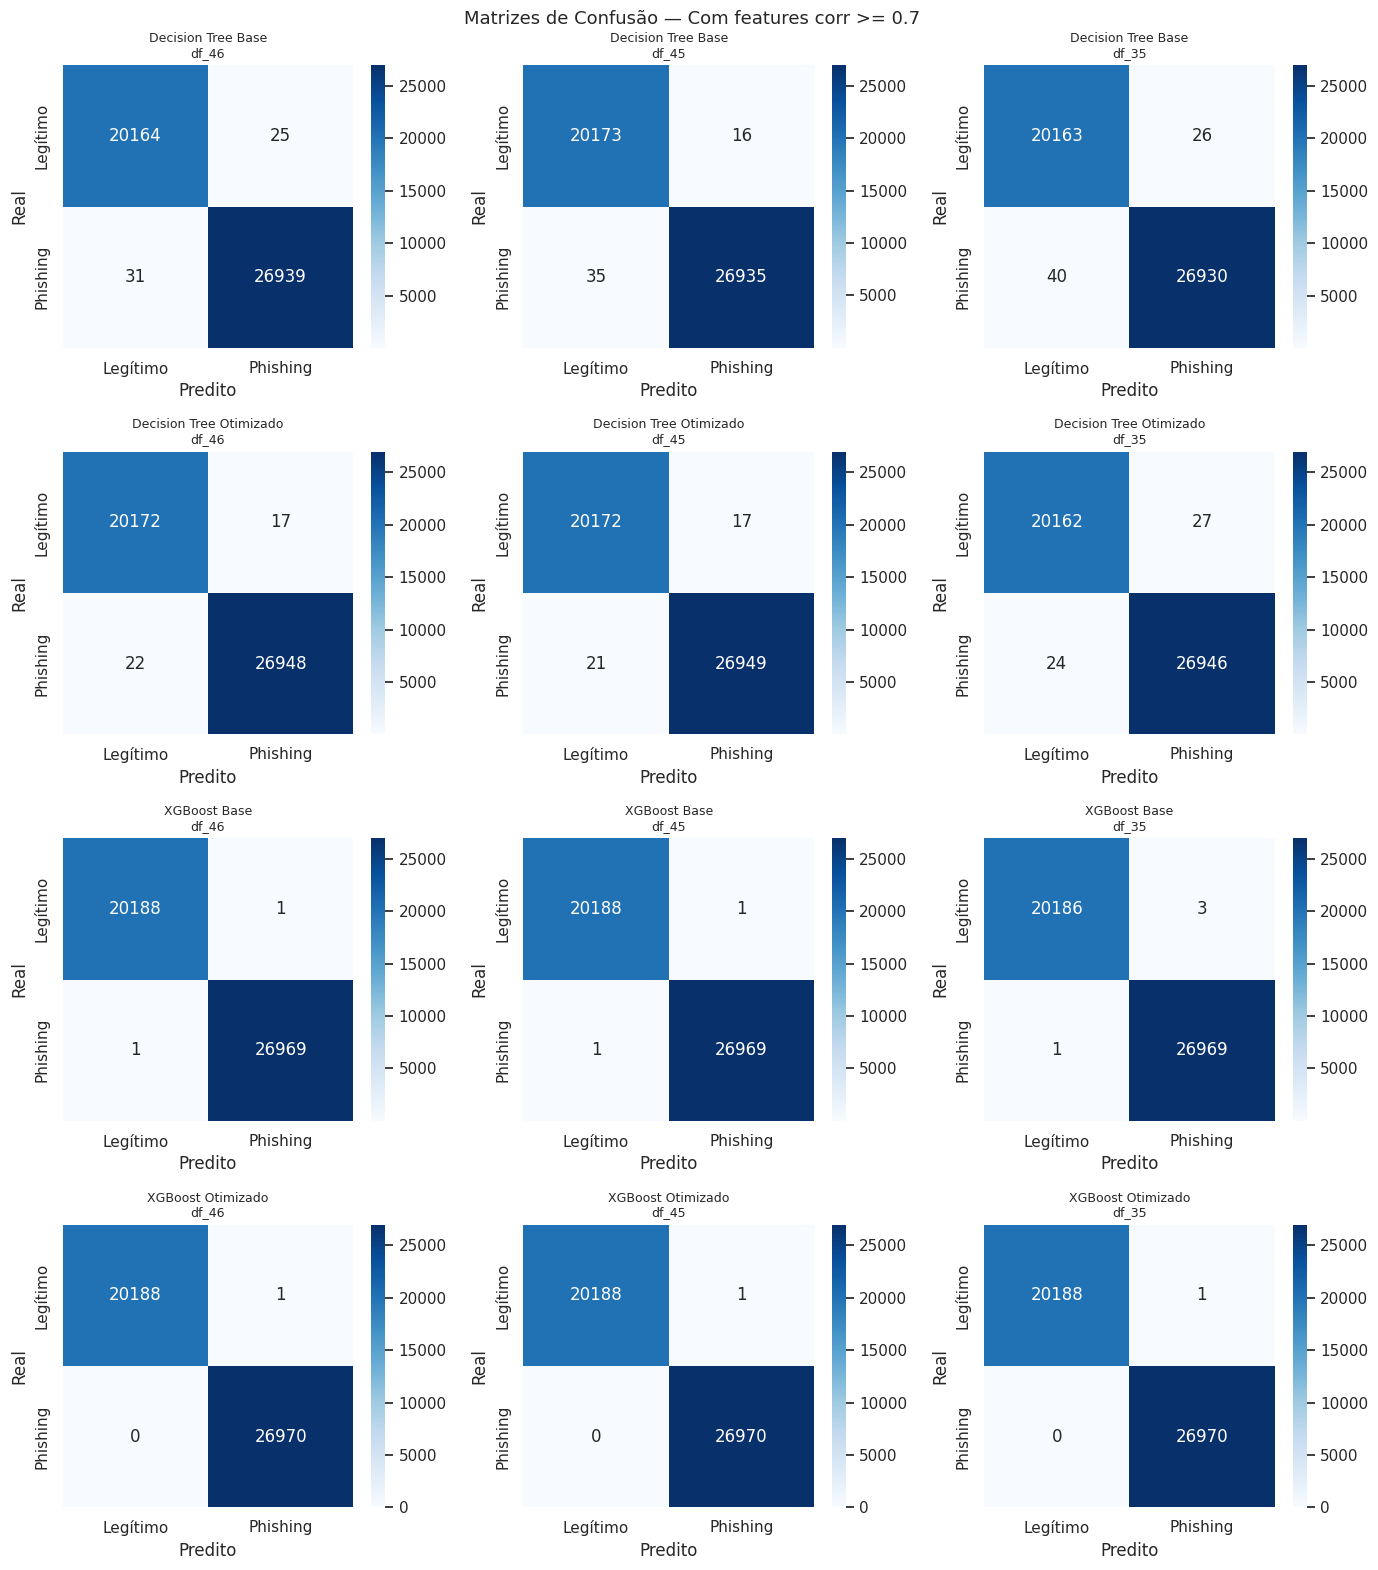


 Sem features corr >= 0.7
Dataset    Modelo                     Precision     Recall         F1   Inferência
------------------------------------------------------------------------------------------
df_46      Decision Tree Base            0.9977     0.9978     0.9977      0.0762s
df_46      Decision Tree Otimizado       0.9988     0.9985     0.9986      0.0103s
df_46      XGBoost Base                  0.9991     0.9997     0.9994      0.1111s
df_46      XGBoost Otimizado             0.9993     0.9997     0.9995      0.2148s
df_45      Decision Tree Base            0.9974     0.9977     0.9975      0.0610s
df_45      Decision Tree Otimizado       0.9988     0.9987     0.9988      0.0103s
df_45      XGBoost Base                  0.9991     0.9997     0.9994      0.1189s
df_45      XGBoost Otimizado             0.9993     0.9997     0.9995      0.2272s
df_35      Decision Tree Base            0.9976     0.9977     0.9976      0.0581s
df_35      Decision Tree Otimizado       0.9986     

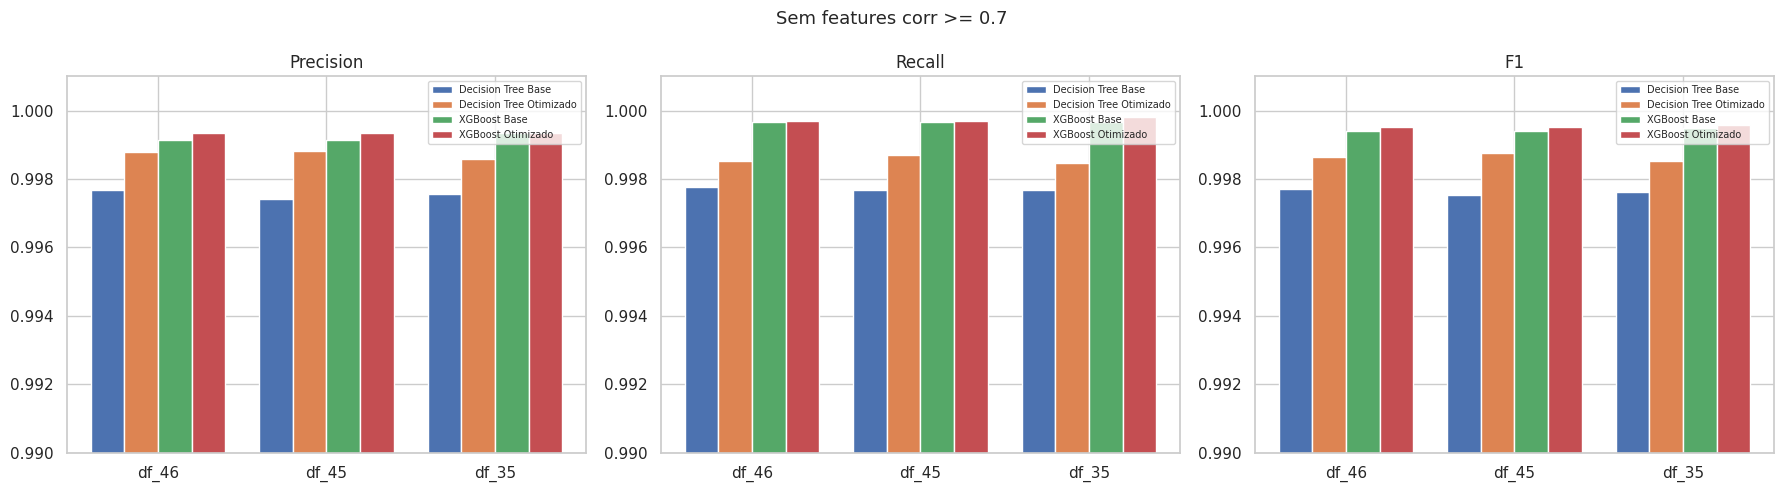

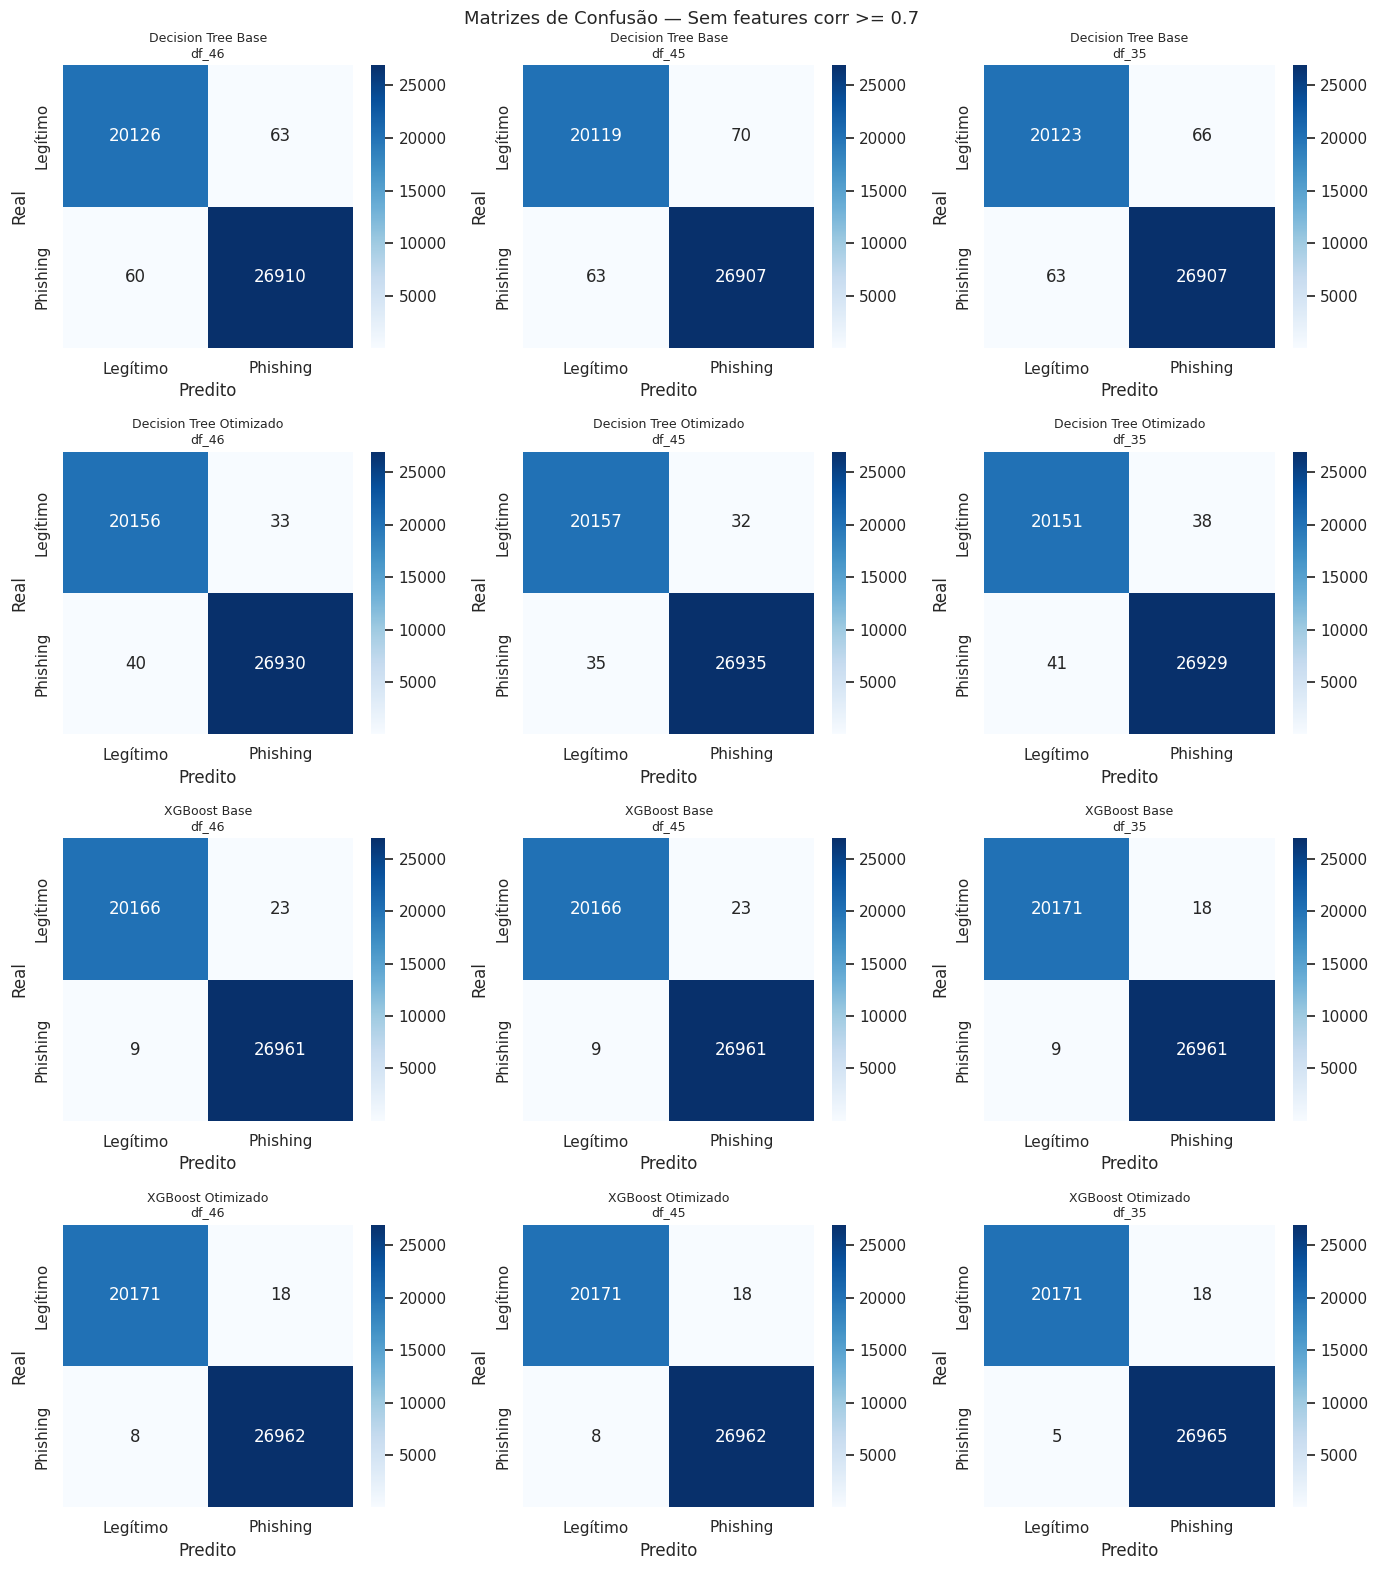

In [35]:
comparar_todos_modelos(resultados_original, splits, 'Com features corr >= 0.7')
comparar_todos_modelos(resultados_sem_leakage, splits_sem_leakage, 'Sem features corr >= 0.7')

## Interpretabilidade dos modelos

- Árvore de decisão: plot da árvore ou ao menos as features mais importantes
- XGBoost: gráfico de feature importance

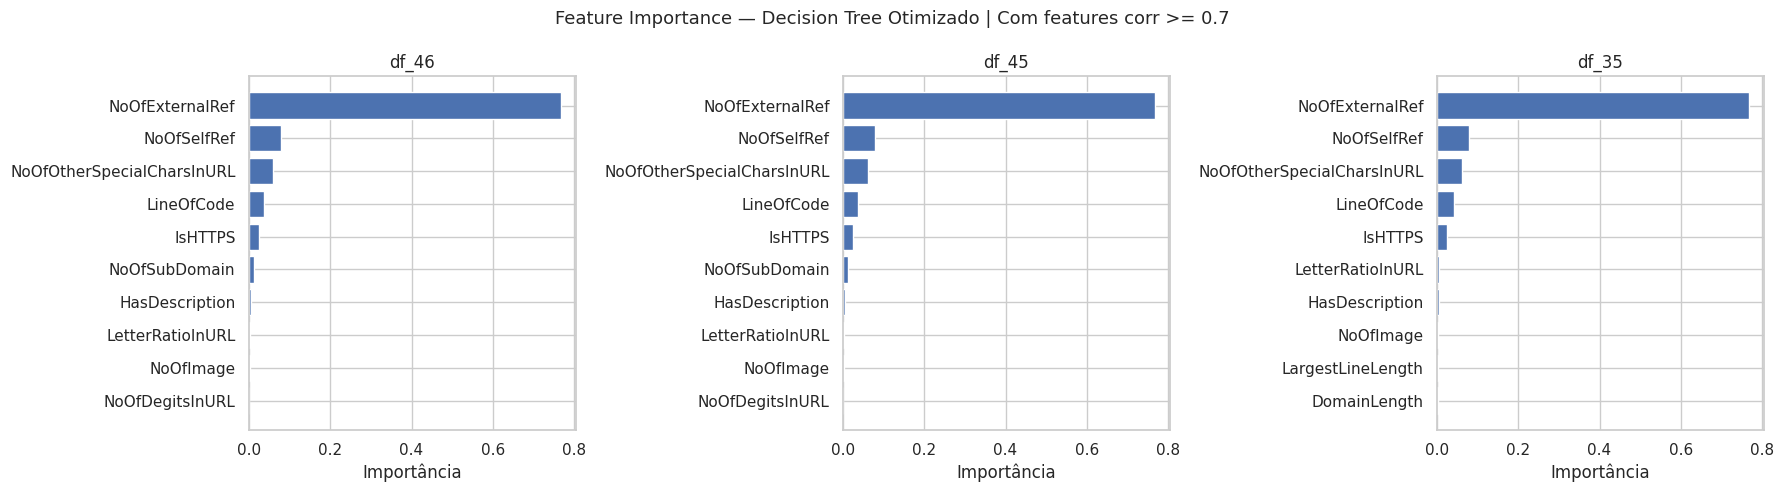

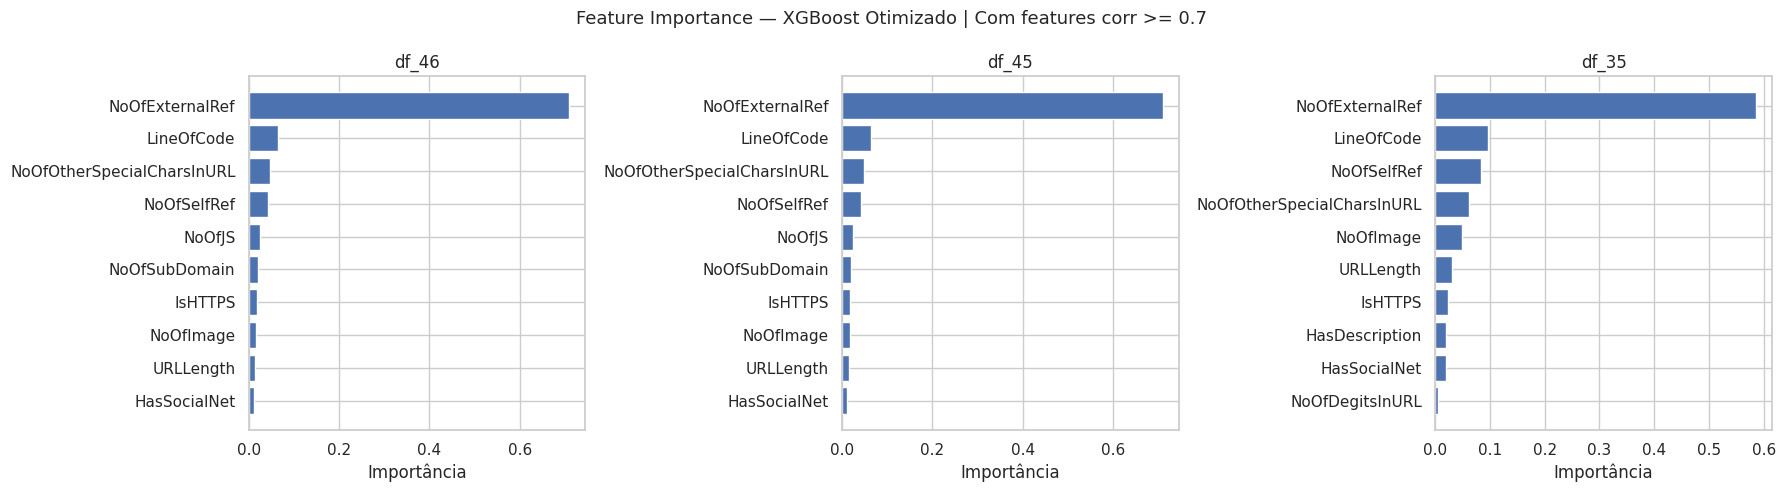


Plot da Árvore de Decisão (df_35, max_depth=5) | Com features corr >= 0.7


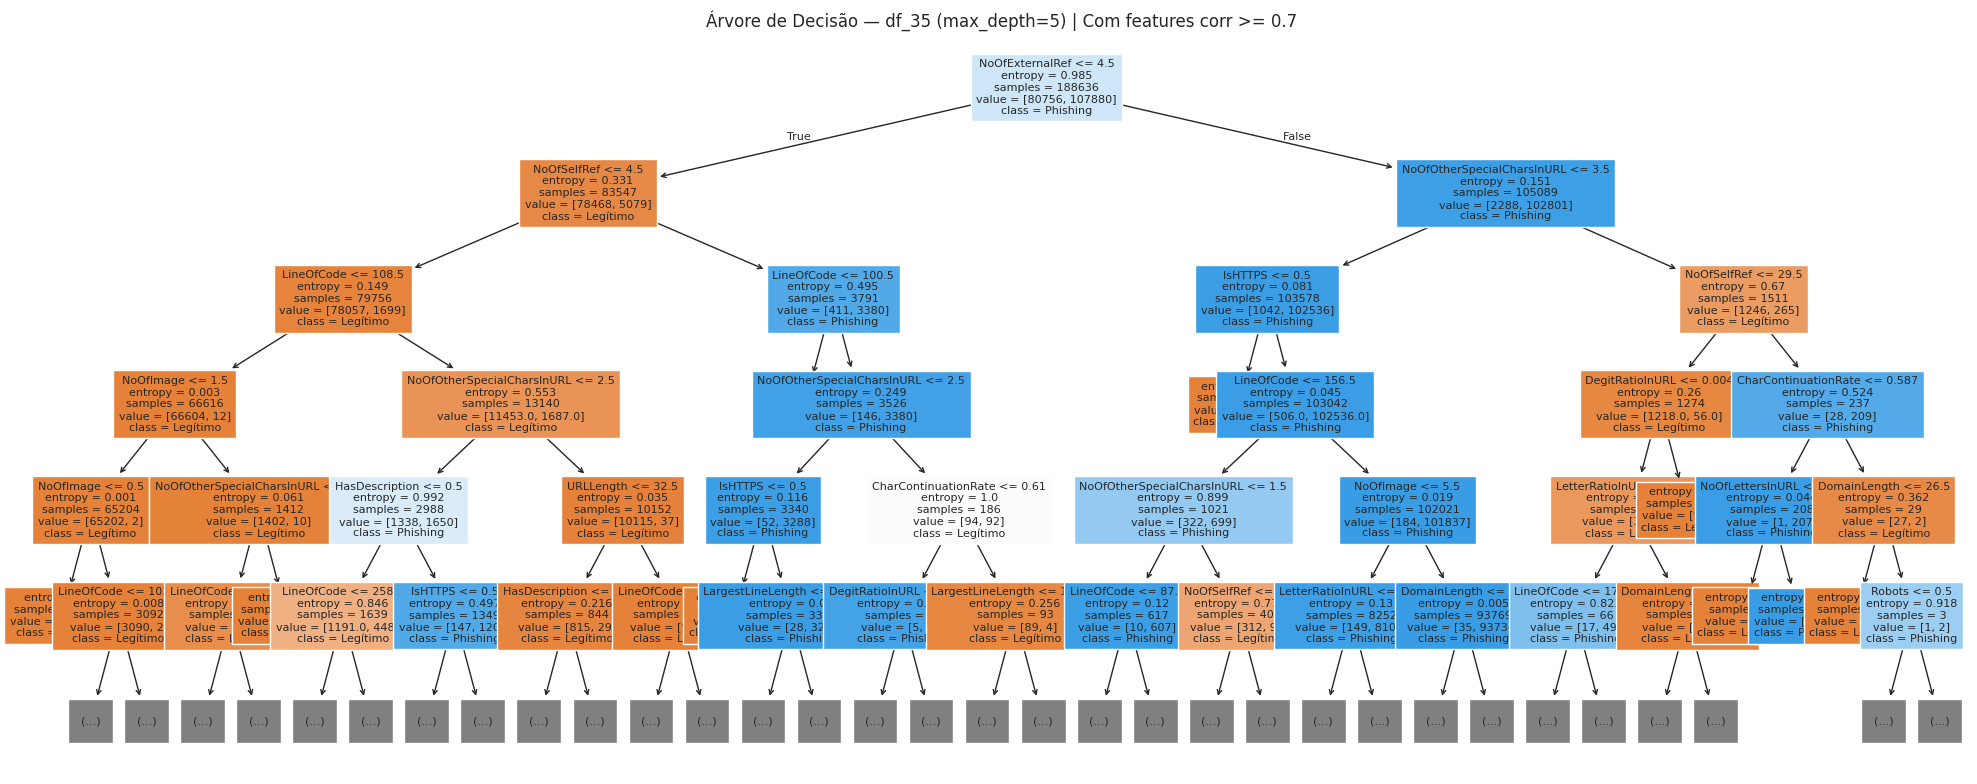

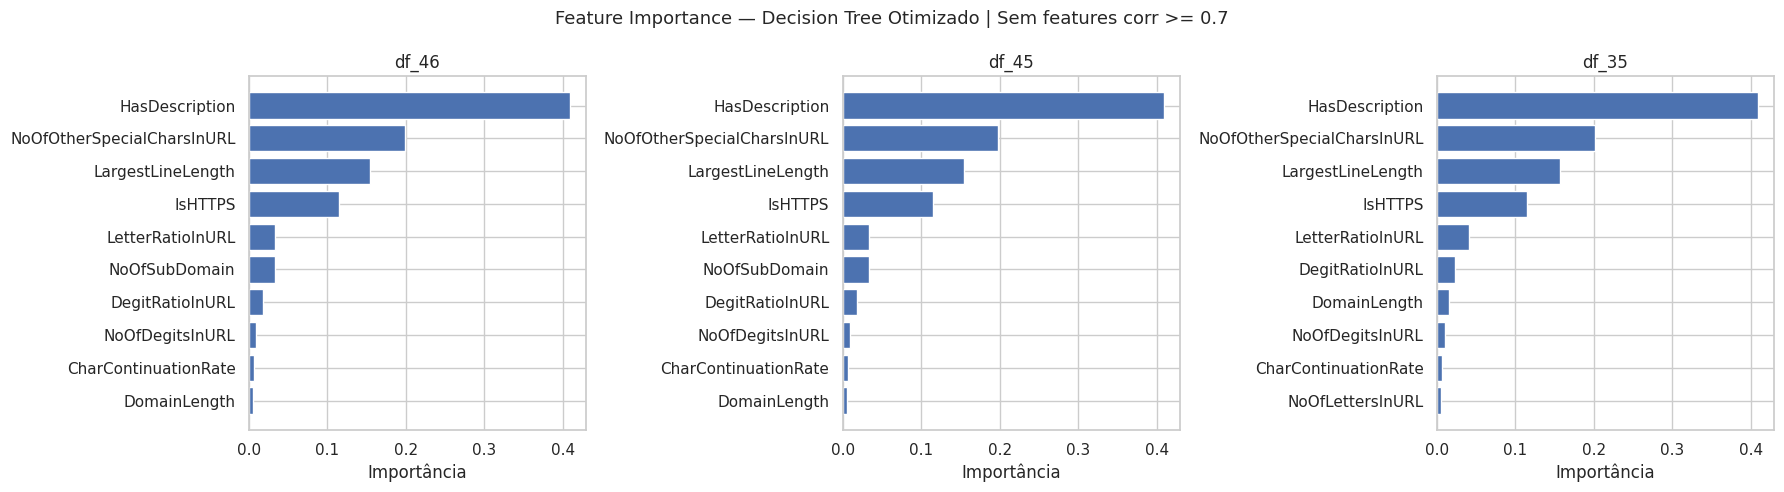

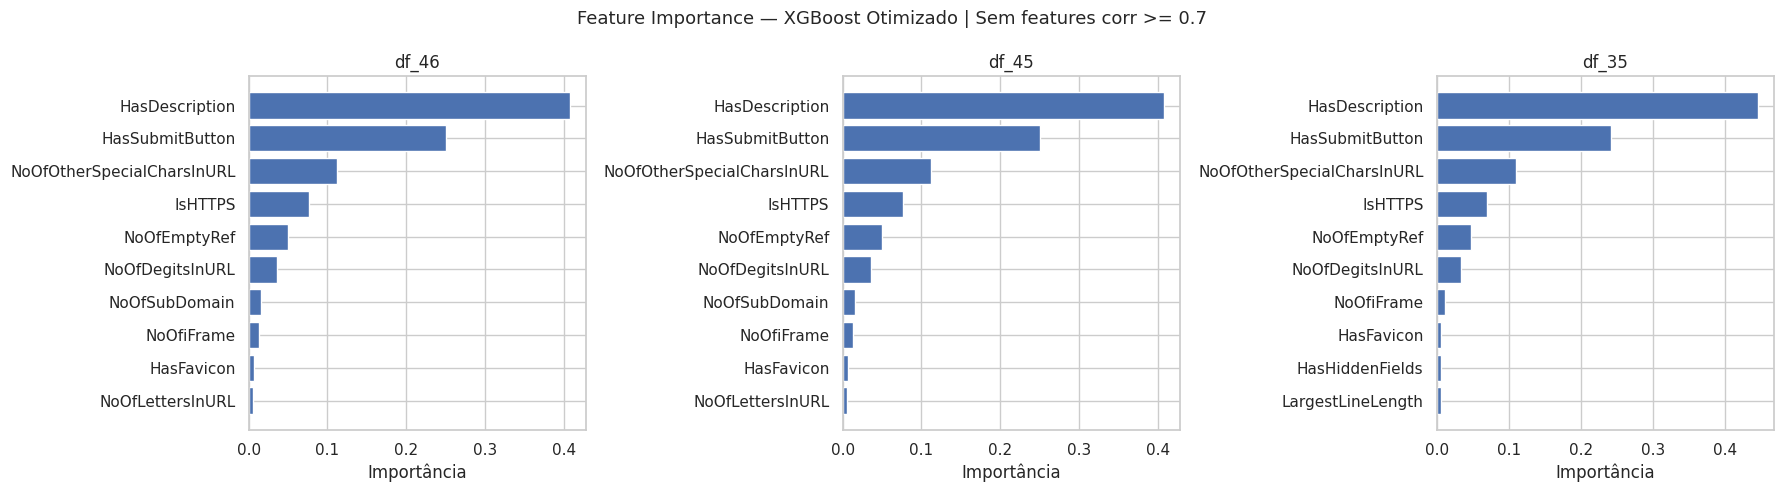


Plot da Árvore de Decisão (df_35, max_depth=5) | Sem features corr >= 0.7


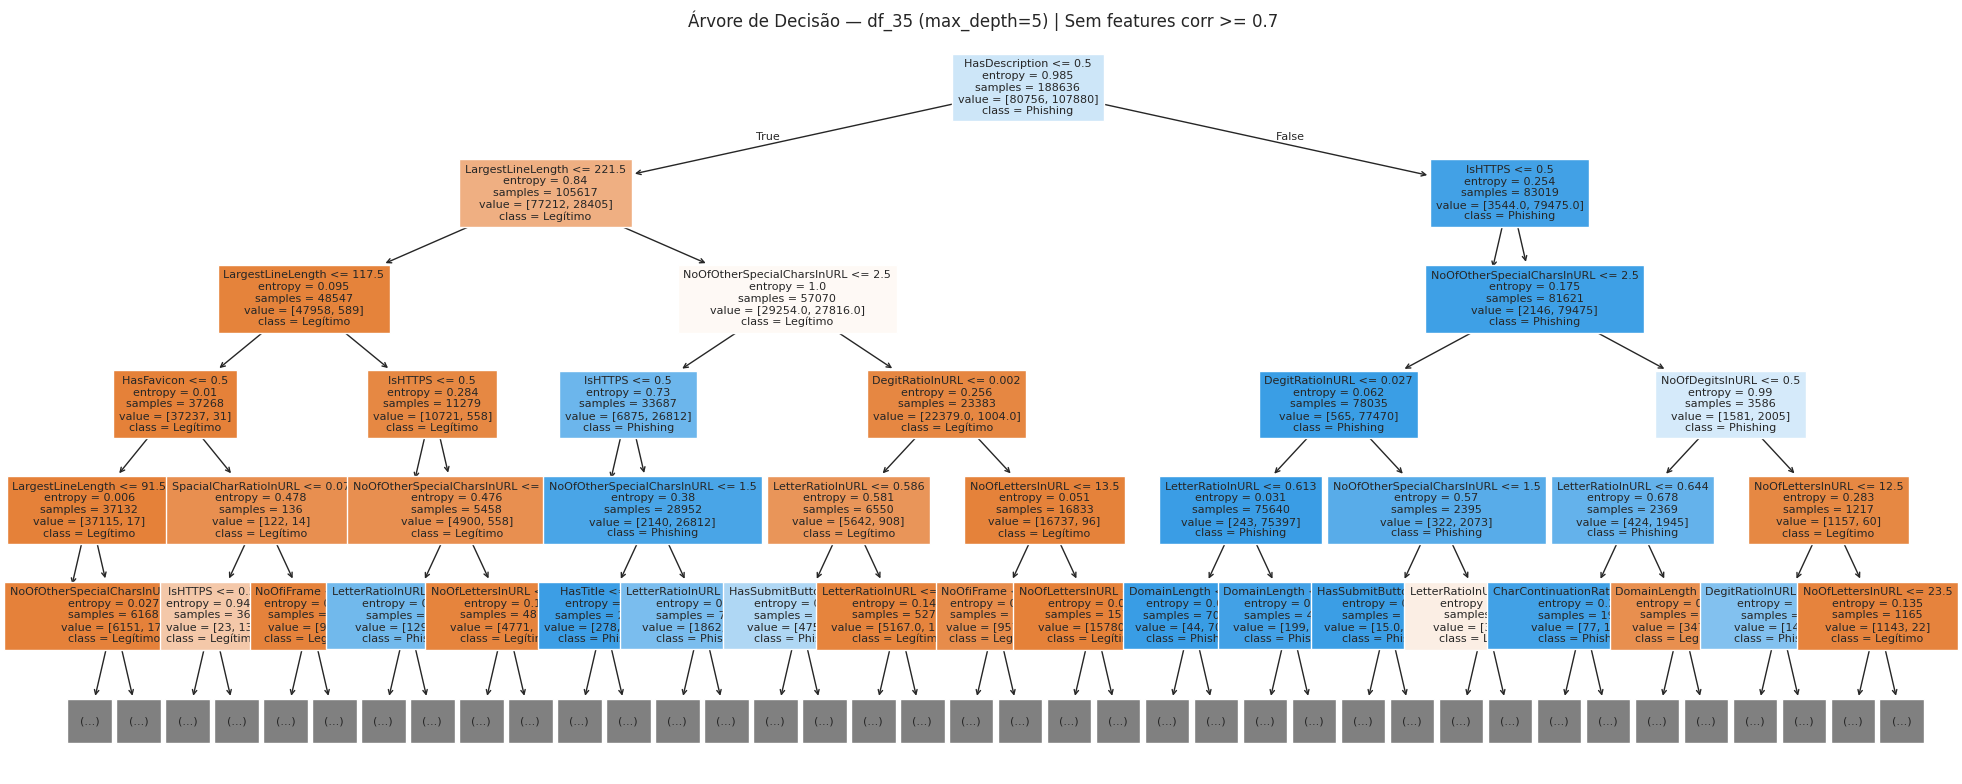

In [34]:
titulo_corr = 'Com features corr >= 0.7'
plotar_importancia_dt(dt_results, splits, titulo_corr)
plotar_importancia_xgb(xgb_results, splits, titulo_corr)
plotar_arvore_decisao(dt_results, splits, titulo_corr, 5)

titulo_sl = 'Sem features corr >= 0.7'
plotar_importancia_dt(dt_results_sl, splits_sem_leakage, titulo_sl)
plotar_importancia_xgb(xgb_results_sl, splits_sem_leakage, titulo_sl)
plotar_arvore_decisao(dt_results_sl, splits_sem_leakage, titulo_sl, 5, dataset_name='df_35')

## Conclusão

A partir dos modelos e experimentos feitos nesse notebook, podemos tirar algumas conclusões:

### O dataset tem suas observações de classes distintas muito separadas

Ficou claro que, mesmo tirando features com correlação muito alta, ao testar o dataset o modelo ainda ficou com métricas muito melhores do que deveria em um cenário real.

Isso indica que o dataset foi estruturalmente construido de maneira que a fronteira entre URLs de phishing e legítimas não são tão misturadas, o que pode ou não ser um reflexo da realidade.

Para o propósito do que queremos fazer, é importante assumir que os atacantes que utilizam do phishing certamente não são tão ingenuos para dar tanto mole em diferentes partes da página ou da URL, e que iriam utilizar de diferentes técnicas para que a nossa extração de métricas não deteque algumas das features mais correlacionadas.

### O tempo de inferência determina qual o melhor modelo

Por conta das métricas precision, recall e F1-Score serem tão proximas umas das outras entre diferentes modelos, fica claro que o tempo de inferência é o grande determinante, pois ao acessar uma página web cada milissegundo pode fazer a diferença para impedir que o código do atacante consiga fazer algo malicioso à vitima.

Com isso, nós temos que o grande vencedor a árvore de decisão otimizada com Grid Search, que é mais rápida que a sua versão base e bem mais rápida que o XGBoost.